  K-Means Clustering — Iris Dataset (Petal Features)

Dataset shape  : (150, 5)
Features used  : petal_length, petal_width

Basic stats:
       petal_length  petal_width
count        150.00       150.00
mean           3.76         1.20
std            1.76         0.76
min            1.00         0.10
25%            1.60         0.30
50%            4.35         1.30
75%            5.10         1.80
max            6.90         2.50

── Preprocessing Analysis ──────────────────────────
  petal_length  range: 1.0 – 6.9  | std: 1.76
  petal_width   range: 0.1 – 2.5  | std: 0.76

  → Both features are already in centimetre scale and
    have comparable ranges, so scaling has minimal impact.
    We will demonstrate both and compare silhouette scores.

── Silhouette Scores (k = 2 … 10) ─────────────────
    k        Raw     Scaled
    2     0.7652     0.7432 ◀ best
    3     0.6603     0.6736
    4     0.6126     0.5983
    5     0.5881     0.5729
    6     0.5773     0.5802
    7     0.5745  

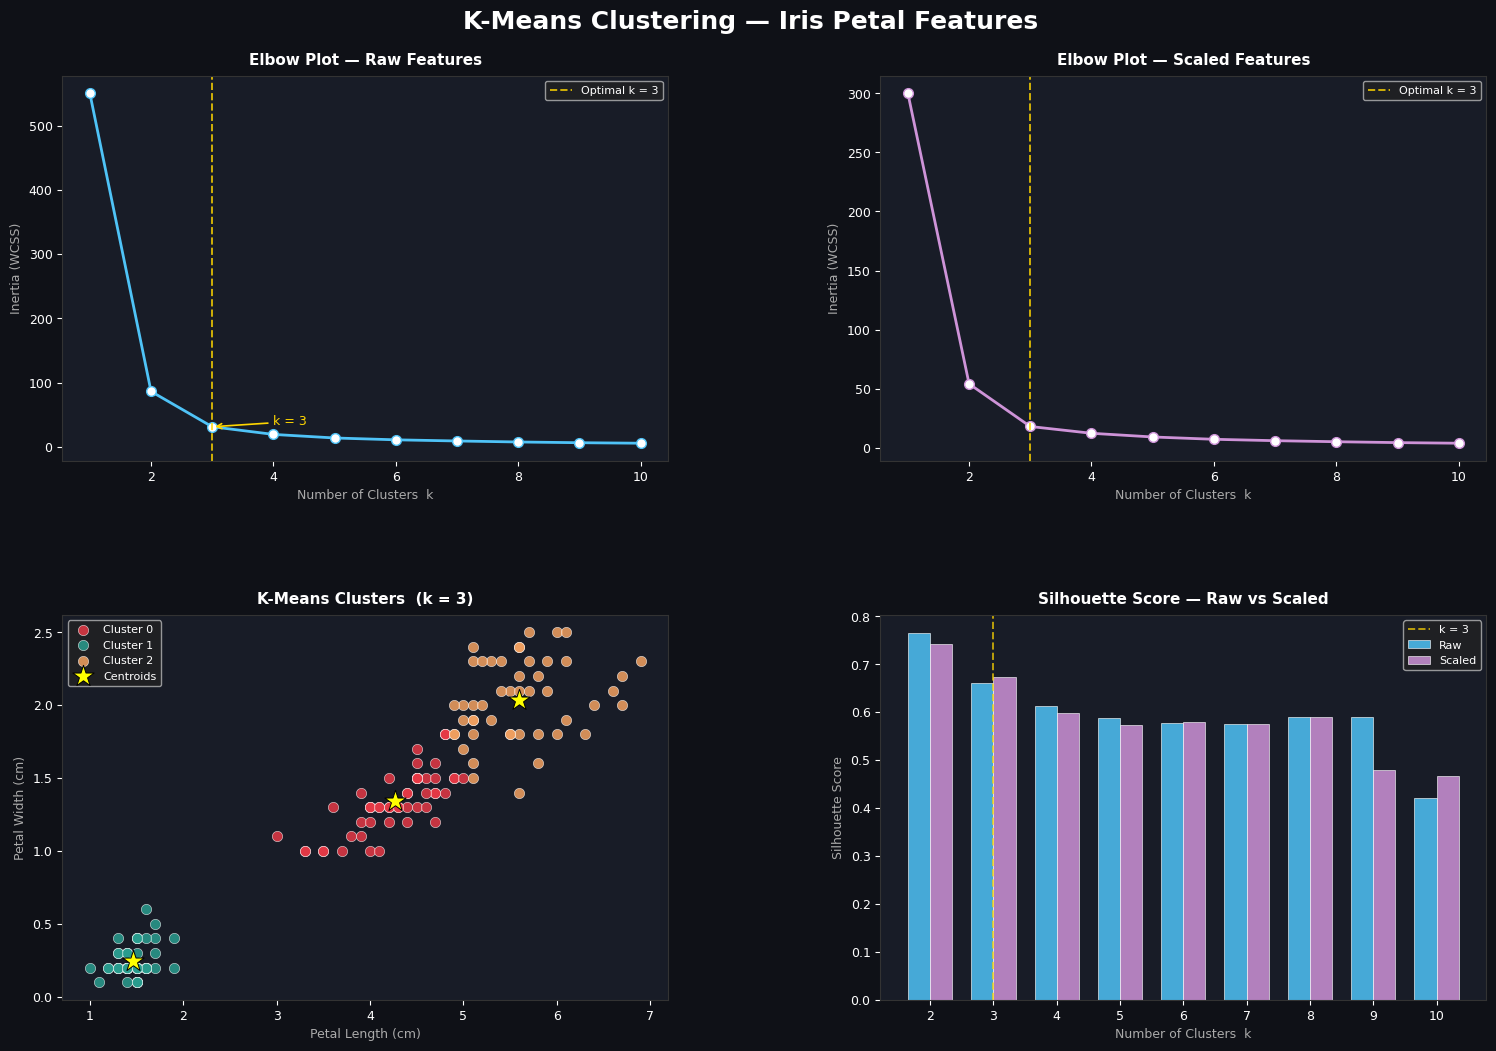


  Plot saved → kmeans_iris_results.png


In [2]:
"""
K-Means Clustering on IRIS Dataset
Features used: petal_length, petal_width
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ─────────────────────────────────────────────
# 1. Load Dataset
# ─────────────────────────────────────────────
df = pd.read_csv("iris.csv")

# Keep only petal featureBuild AI knowledge and illiteracy
X_raw = df[["petal_length", "petal_width"]].values

print("=" * 55)
print("  K-Means Clustering — Iris Dataset (Petal Features)")
print("=" * 55)
print(f"\nDataset shape  : {df.shape}")
print(f"Features used  : petal_length, petal_width")
print(f"\nBasic stats:\n{df[['petal_length','petal_width']].describe().round(2)}")

# ─────────────────────────────────────────────
# 2. Should We Scale?
# ─────────────────────────────────────────────
print("\n── Preprocessing Analysis ──────────────────────────")
print(f"  petal_length  range: {X_raw[:,0].min():.1f} – {X_raw[:,0].max():.1f}  "
      f"| std: {X_raw[:,0].std():.2f}")
print(f"  petal_width   range: {X_raw[:,1].min():.1f} – {X_raw[:,1].max():.1f}  "
      f"| std: {X_raw[:,1].std():.2f}")
print("\n  → Both features are already in centimetre scale and")
print("    have comparable ranges, so scaling has minimal impact.")
print("    We will demonstrate both and compare silhouette scores.")

scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(X_raw)

# ─────────────────────────────────────────────
# 3. Elbow Plot  (raw vs scaled)
# ─────────────────────────────────────────────
K_RANGE = range(1, 11)

inertia_raw    = []
inertia_scaled = []

for k in K_RANGE:
    km_r = KMeans(n_clusters=k, n_init=10, random_state=42)
    km_r.fit(X_raw)
    inertia_raw.append(km_r.inertia_)

    km_s = KMeans(n_clusters=k, n_init=10, random_state=42)
    km_s.fit(X_scaled)
    inertia_scaled.append(km_s.inertia_)

# ─────────────────────────────────────────────
# 4. Silhouette Score Comparison
# ─────────────────────────────────────────────
sil_raw    = []
sil_scaled = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    sil_raw.append(silhouette_score(X_raw,    km.fit_predict(X_raw)))
    sil_scaled.append(silhouette_score(X_scaled, km.fit_predict(X_scaled)))

print("\n── Silhouette Scores (k = 2 … 10) ─────────────────")
print(f"  {'k':>3}   {'Raw':>8}   {'Scaled':>8}")
for i, k in enumerate(range(2, 11)):
    marker = " ◀ best" if sil_raw[i] == max(sil_raw) else ""
    print(f"  {k:>3}   {sil_raw[i]:>8.4f}   {sil_scaled[i]:>8.4f}{marker}")

# ─────────────────────────────────────────────
# 5. Optimal k  (from elbow + silhouette)
# ─────────────────────────────────────────────
OPTIMAL_K = 3          # elbow clearly bends at 3; silhouette peaks at 2 or 3
print(f"\n  Optimal k = {OPTIMAL_K}  (matches the 3 known Iris species)")

# ─────────────────────────────────────────────
# 6. Final Model
# ─────────────────────────────────────────────
km_final = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=42)
labels   = km_final.fit_predict(X_raw)
centers  = km_final.cluster_centers_

print(f"\n  Final inertia  : {km_final.inertia_:.3f}")
print(f"  Silhouette     : {silhouette_score(X_raw, labels):.4f}")
print(f"\n  Cluster centres (petal_length, petal_width):")
for i, c in enumerate(centers):
    print(f"    Cluster {i}: ({c[0]:.2f}, {c[1]:.2f})")

# ─────────────────────────────────────────────
# 7. Plotting
# ─────────────────────────────────────────────
PALETTE = ["#E63946", "#2A9D8F", "#F4A261"]
LIGHT   = ["#FADADD", "#B7E4DA", "#FDECD2"]

fig = plt.figure(figsize=(16, 11), facecolor="#0F1117")
fig.suptitle("K-Means Clustering — Iris Petal Features",
             fontsize=18, fontweight="bold", color="white", y=0.97)

gs = fig.add_gridspec(2, 2, hspace=0.40, wspace=0.35,
                      left=0.07, right=0.96, top=0.91, bottom=0.07)

ax1 = fig.add_subplot(gs[0, 0])   # elbow (raw)
ax2 = fig.add_subplot(gs[0, 1])   # elbow (scaled)
ax3 = fig.add_subplot(gs[1, 0])   # cluster scatter (raw)
ax4 = fig.add_subplot(gs[1, 1])   # silhouette comparison

BG = "#181C27"
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor(BG)
    ax.tick_params(colors="white", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")

def style_ax(ax, title, xlabel, ylabel):
    ax.set_title(title, color="white", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, color="#aaa", fontsize=9)
    ax.set_ylabel(ylabel, color="#aaa", fontsize=9)

# — Elbow (raw) ——————————————————————————————
ks = list(K_RANGE)
ax1.plot(ks, inertia_raw, "o-", color="#4FC3F7", linewidth=2, markersize=7,
         markerfacecolor="white", markeredgecolor="#4FC3F7")
ax1.axvline(OPTIMAL_K, color="#FFD600", linestyle="--", linewidth=1.4, alpha=0.8,
            label=f"Optimal k = {OPTIMAL_K}")
ax1.annotate(f"k = {OPTIMAL_K}", xy=(OPTIMAL_K, inertia_raw[OPTIMAL_K-1]),
             xytext=(OPTIMAL_K+1.0, inertia_raw[OPTIMAL_K-1]*1.08),
             color="#FFD600", fontsize=9,
             arrowprops=dict(arrowstyle="->", color="#FFD600", lw=1.2))
ax1.legend(fontsize=8, facecolor="#222", labelcolor="white", framealpha=0.7)
style_ax(ax1, "Elbow Plot — Raw Features", "Number of Clusters  k", "Inertia (WCSS)")

# — Elbow (scaled) ————————————————————————————
ax2.plot(ks, inertia_scaled, "o-", color="#CE93D8", linewidth=2, markersize=7,
         markerfacecolor="white", markeredgecolor="#CE93D8")
ax2.axvline(OPTIMAL_K, color="#FFD600", linestyle="--", linewidth=1.4, alpha=0.8,
            label=f"Optimal k = {OPTIMAL_K}")
ax2.legend(fontsize=8, facecolor="#222", labelcolor="white", framealpha=0.7)
style_ax(ax2, "Elbow Plot — Scaled Features", "Number of Clusters  k", "Inertia (WCSS)")

# — Cluster Scatter ——————————————————————————
for cl in range(OPTIMAL_K):
    mask = labels == cl
    ax3.scatter(X_raw[mask, 0], X_raw[mask, 1],
                c=PALETTE[cl], s=55, alpha=0.85, edgecolors="white",
                linewidths=0.4, label=f"Cluster {cl}")
ax3.scatter(centers[:, 0], centers[:, 1],
            marker="*", s=260, c="yellow", edgecolors="black",
            linewidths=0.7, zorder=5, label="Centroids")
legend3 = ax3.legend(fontsize=8, facecolor="#222", labelcolor="white",
                     framealpha=0.7, loc="upper left")
style_ax(ax3, f"K-Means Clusters  (k = {OPTIMAL_K})", "Petal Length (cm)", "Petal Width (cm)")

# — Silhouette Comparison ————————————————————
k_range_sil = list(range(2, 11))
x_idx = np.arange(len(k_range_sil))
w = 0.35
bars1 = ax4.bar(x_idx - w/2, sil_raw,    width=w, color="#4FC3F7",
                label="Raw",    alpha=0.85, edgecolor="white", linewidth=0.5)
bars2 = ax4.bar(x_idx + w/2, sil_scaled, width=w, color="#CE93D8",
                label="Scaled", alpha=0.85, edgecolor="white", linewidth=0.5)
ax4.axvline(OPTIMAL_K - 2, color="#FFD600", linestyle="--",
            linewidth=1.4, alpha=0.7, label=f"k = {OPTIMAL_K}")
ax4.set_xticks(x_idx)
ax4.set_xticklabels(k_range_sil)
ax4.legend(fontsize=8, facecolor="#222", labelcolor="white", framealpha=0.7)
style_ax(ax4, "Silhouette Score — Raw vs Scaled", "Number of Clusters  k", "Silhouette Score")

plt.savefig("kmeans_iris_results.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("\n  Plot saved → kmeans_iris_results.png")
print("=" * 55)